# Wastewater Quality Prediction

### Importing Libraries

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
df = pd.read_csv("synthetic_wwtp_v2.csv")

In [26]:
df.head(5)

,Q-E,PH-E,DBO-E,DQO-E,SS-E,PH-S,DBO-S,DQO-S,SS-S,BOD_removal
0,40980.3,8.12,179.5,360.6,176.8,7.60,17.1,56.3,12.2,90.47
1,37170.4,7.98,211.3,446.7,218.4,7.67,20.9,58.7,15.0,90.13
2,41886.1,7.72,172.5,372.3,220.9,7.64,21.5,68.5,22.3,87.53
3,47138.2,7.51,201.5,481.4,243.6,7.55,28.1,91.4,34.2,86.07
4,36595.1,7.91,106.4,240.0,151.7,7.70,3.5,23.2,3.6,96.67


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Q-E          1000 non-null   float64
 1   PH-E         1000 non-null   float64
 2   DBO-E        1000 non-null   float64
 3   DQO-E        1000 non-null   float64
 4   SS-E         1000 non-null   float64
 5   PH-S         1000 non-null   float64
 6   DBO-S        1000 non-null   float64
 7   DQO-S        1000 non-null   float64
 8   SS-S         1000 non-null   float64
 9   BOD_removal  1000 non-null   float64
dtypes: float64(10)
memory usage: 78.3 KB


#### Data is clean with no null cells, so no need for cleaning

#### Plots for BOD, COD, Solid substance and PH at inlet and outlet

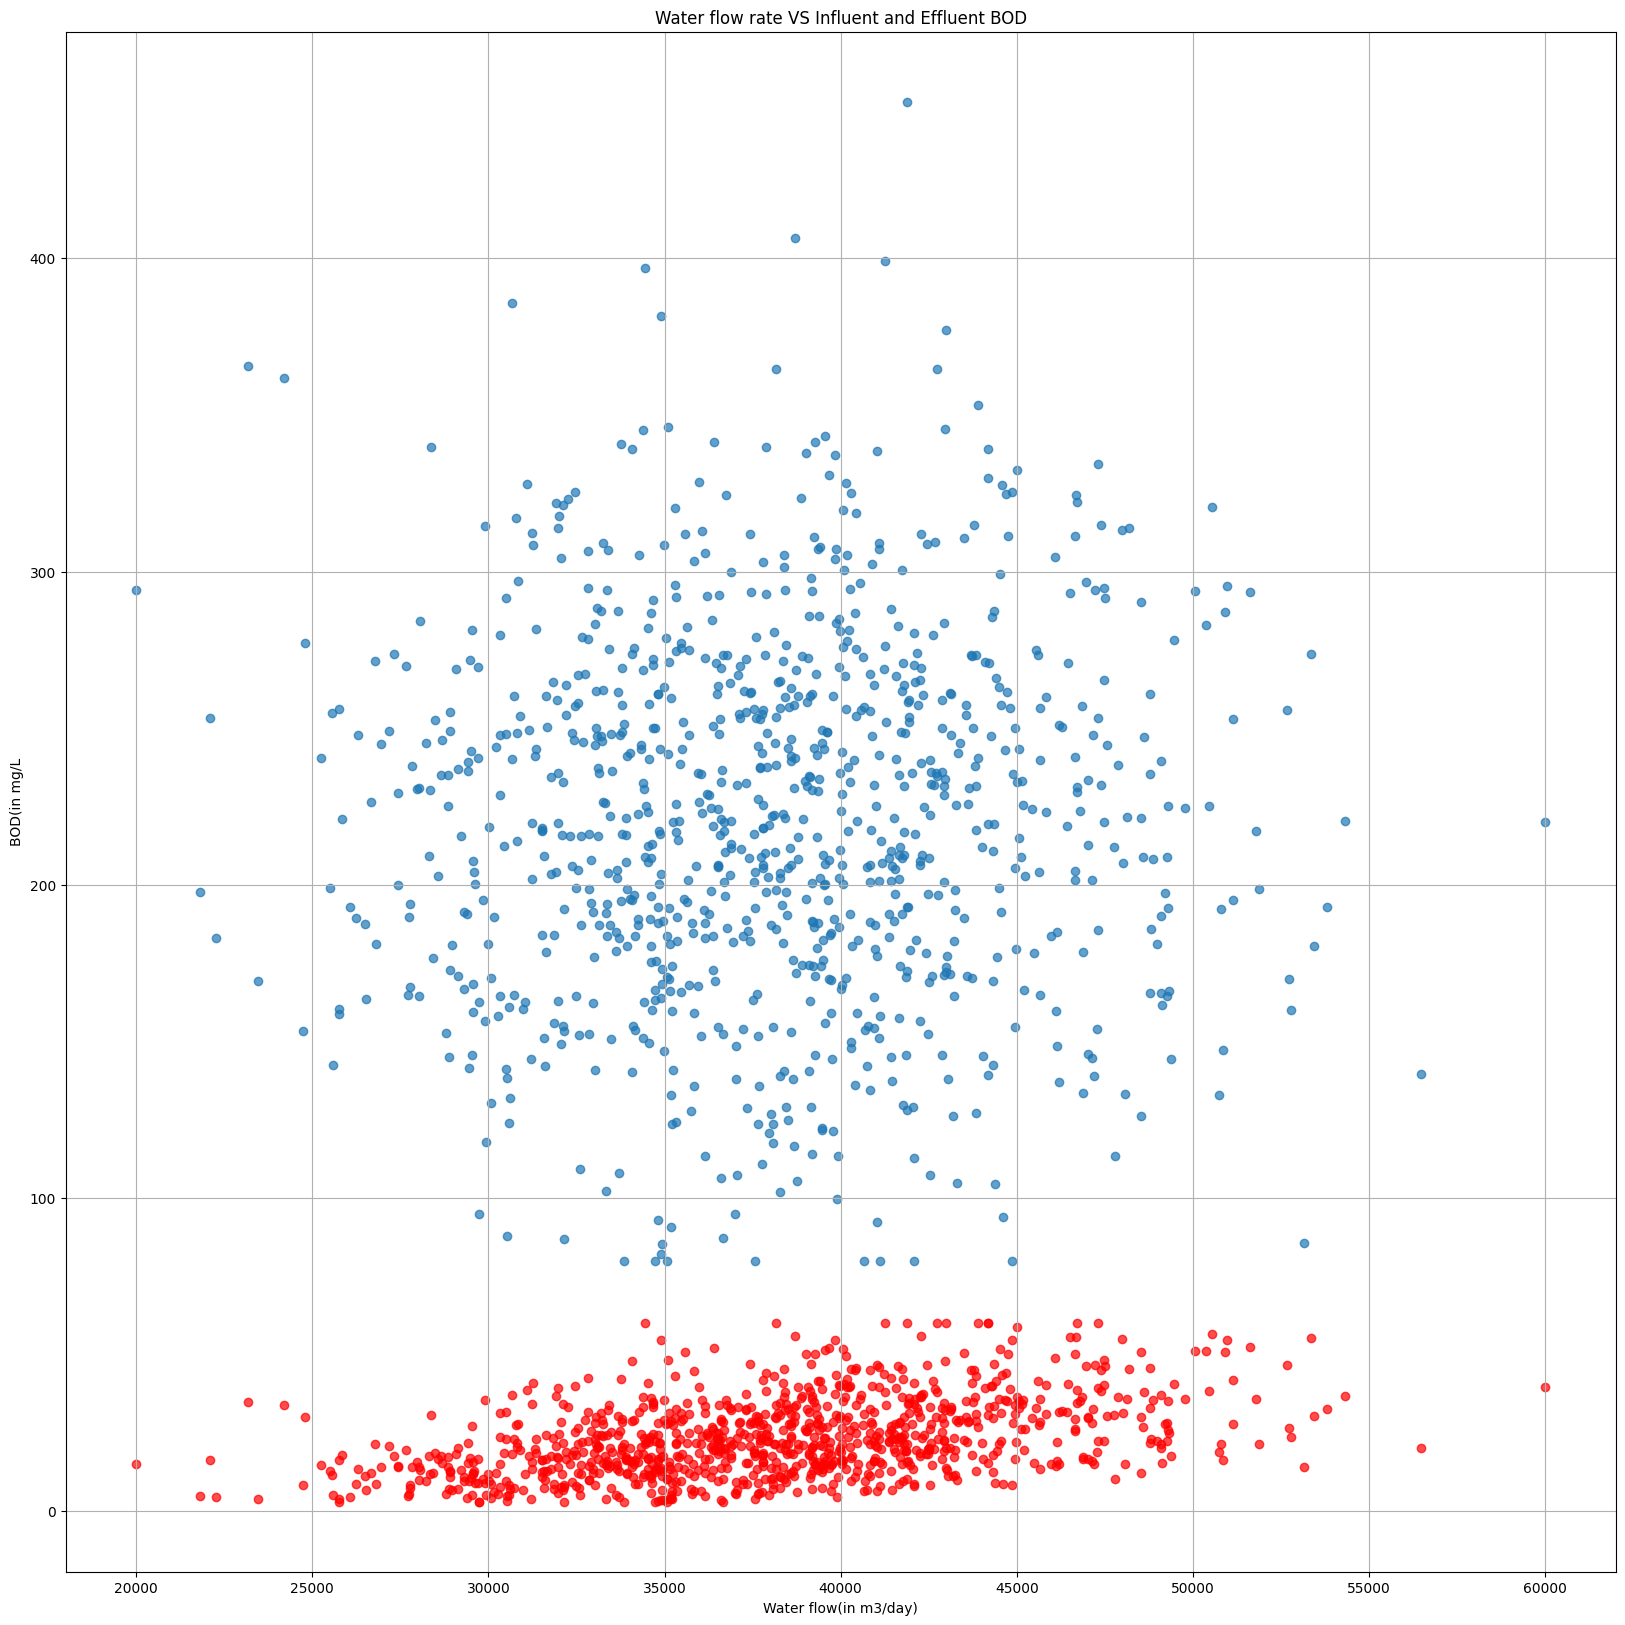

In [28]:
plt.figure(figsize = (20,20))
plt.scatter(df['Q-E'],df['DBO-E'],alpha = 0.7)
plt.scatter(df['Q-E'],df['DBO-S'],color = 'red',alpha = 0.7)
plt.xlabel("Water flow(in m3/day)")
plt.ylabel("BOD(in mg/L")
plt.title("Water flow rate VS Influent and Effluent BOD")
plt.grid(True)
plt.show()

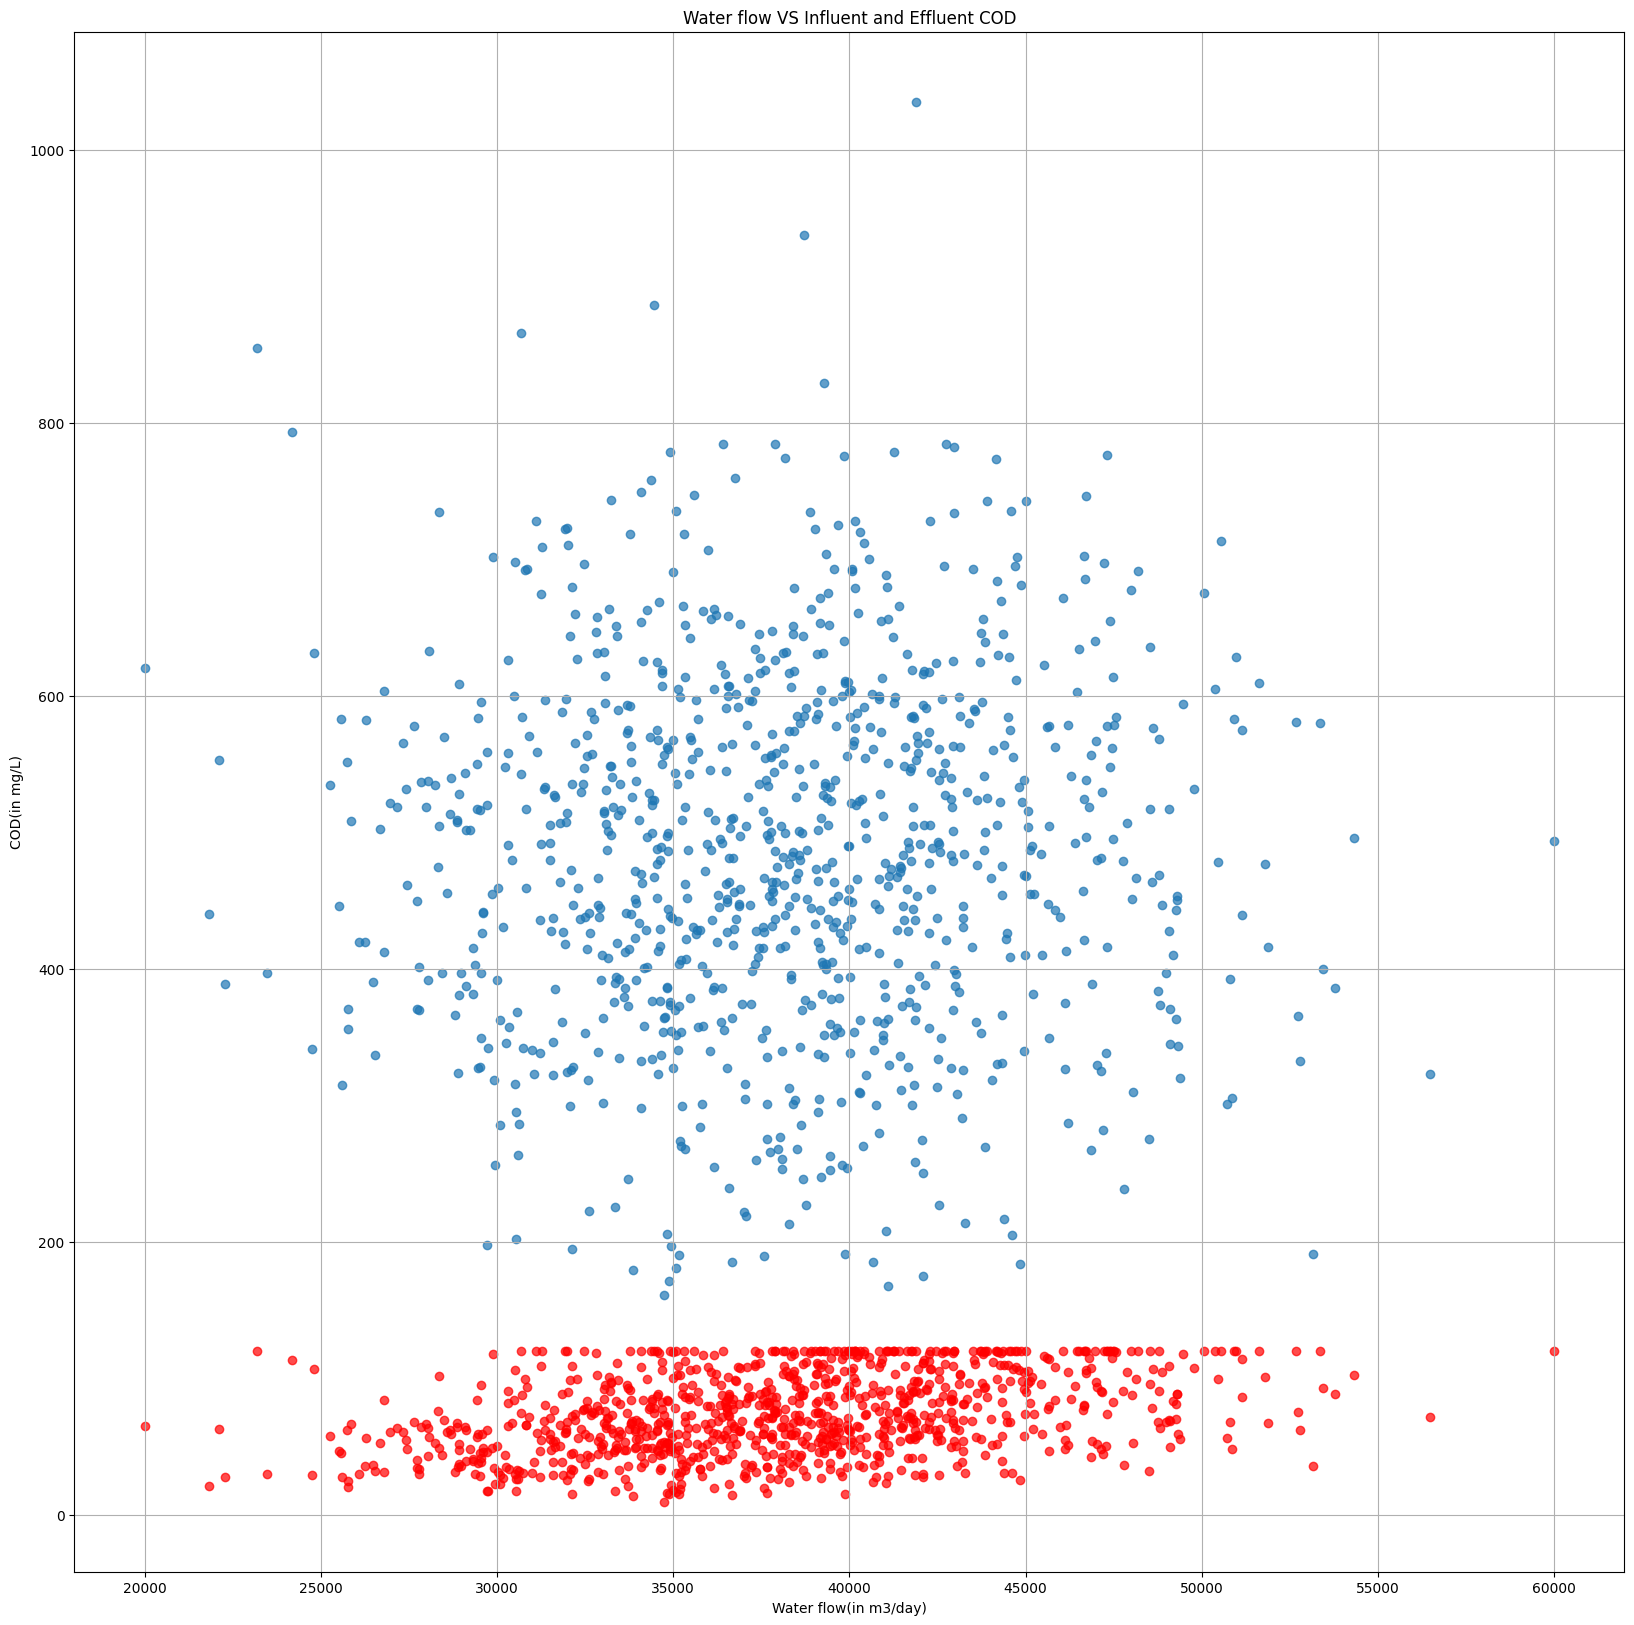

In [29]:
plt.figure(figsize = (20,20))
plt.scatter(df['Q-E'],df['DQO-E'],alpha =0.7)
plt.scatter(df['Q-E'],df['DQO-S'],color = 'red',alpha =0.7)
plt.xlabel("Water flow(in m3/day)")
plt.ylabel('COD(in mg/L)')
plt.title('Water flow VS Influent and Effluent COD')
plt.grid(True)
plt.show()

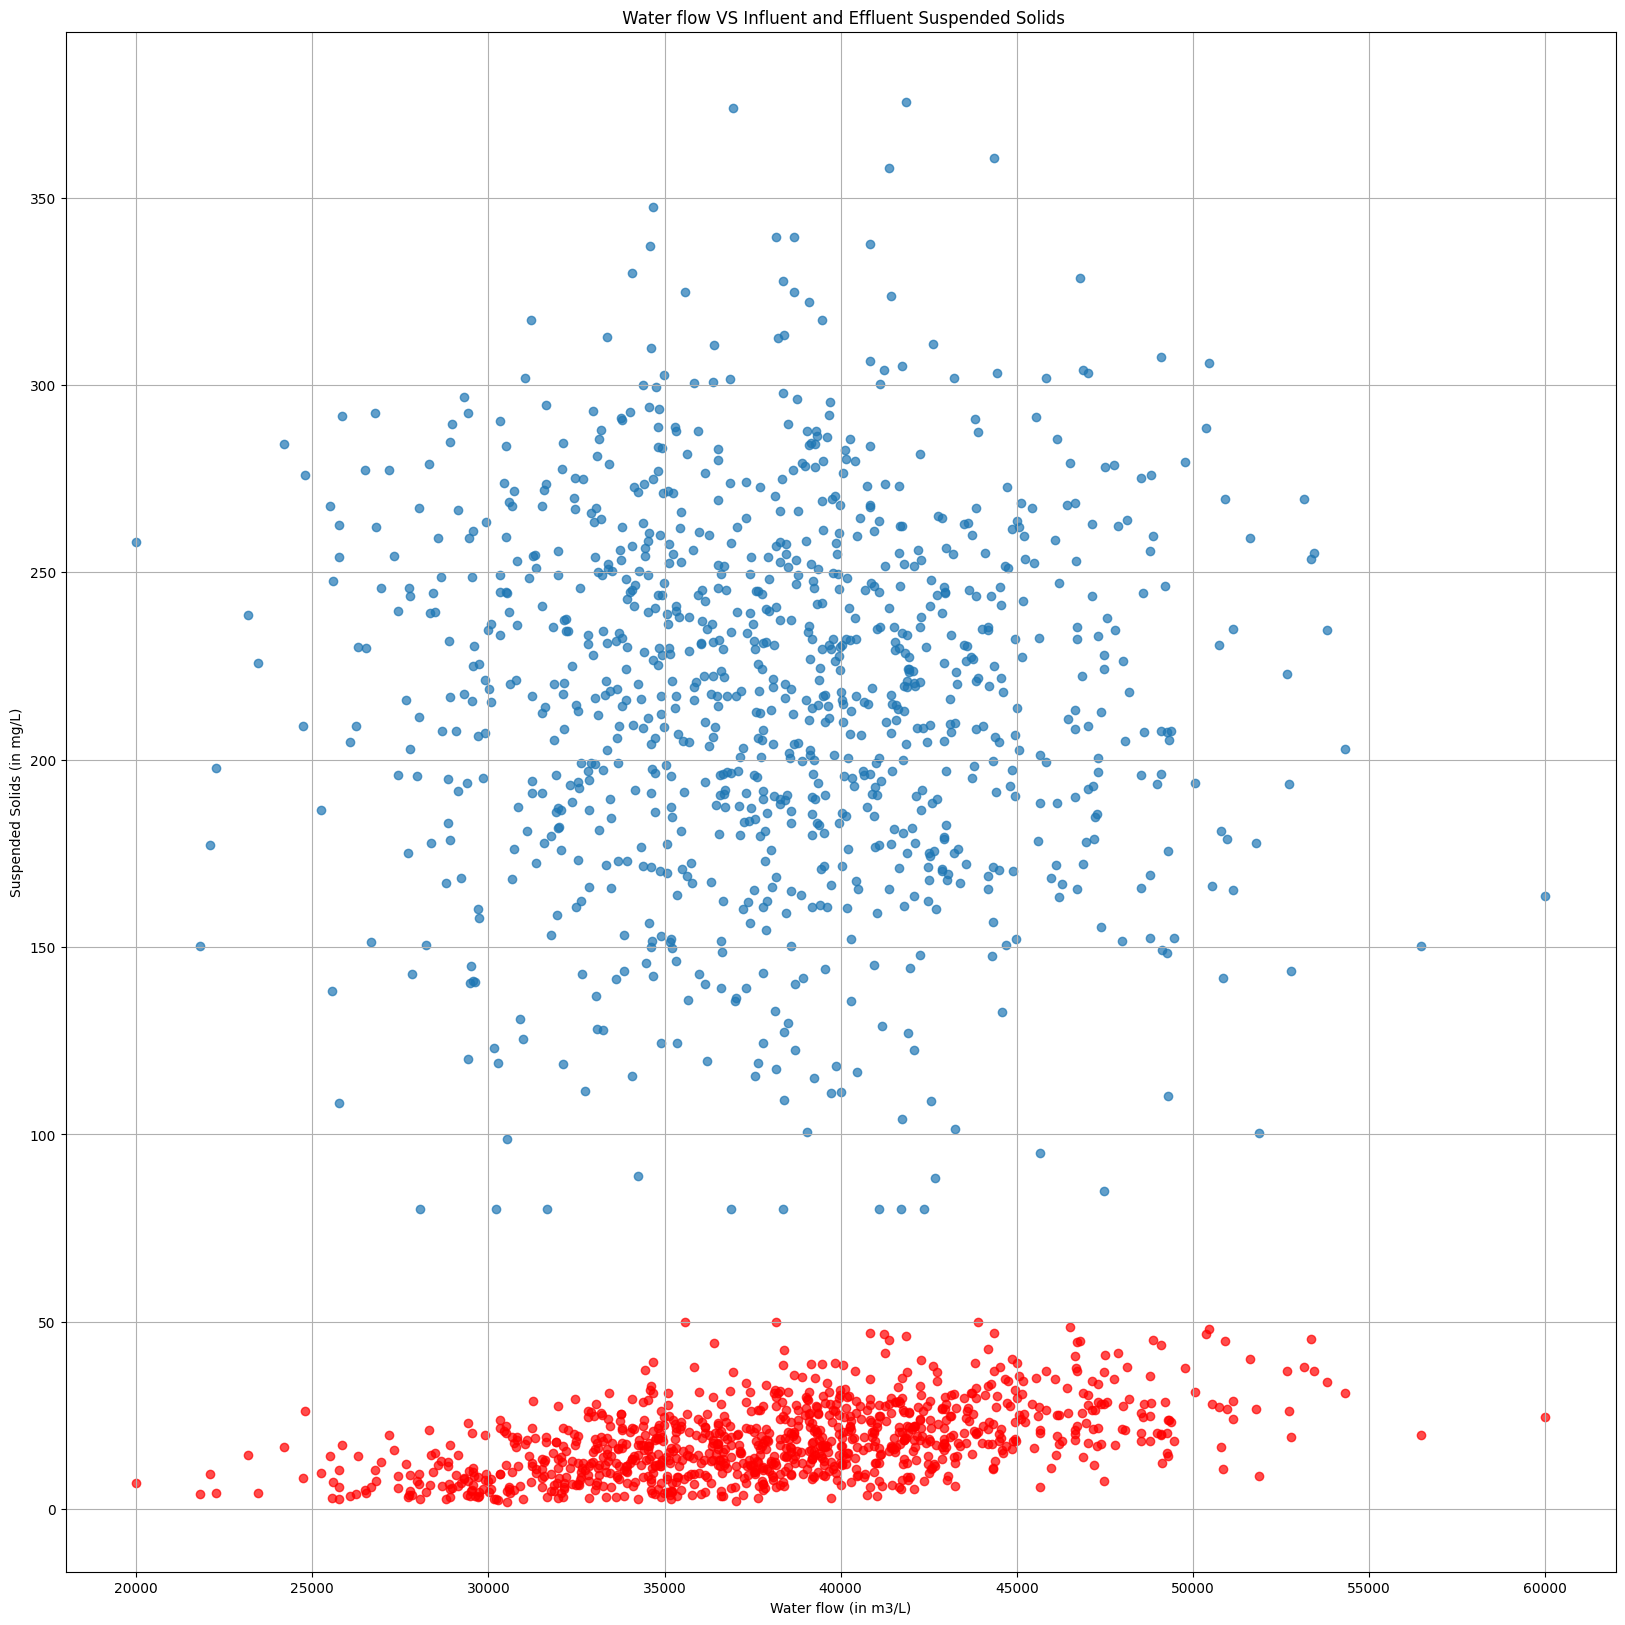

In [30]:
plt.figure(figsize=(20,20))
plt.scatter(df['Q-E'],df['SS-E'],alpha =0.7)
plt.scatter(df['Q-E'],df['SS-S'],color = 'red',alpha =0.7)
plt.xlabel('Water flow (in m3/L)')
plt.ylabel('Suspended Solids (in mg/L)')
plt.title(' Water flow VS Influent and Effluent Suspended Solids')
plt.grid(True)
plt.show()

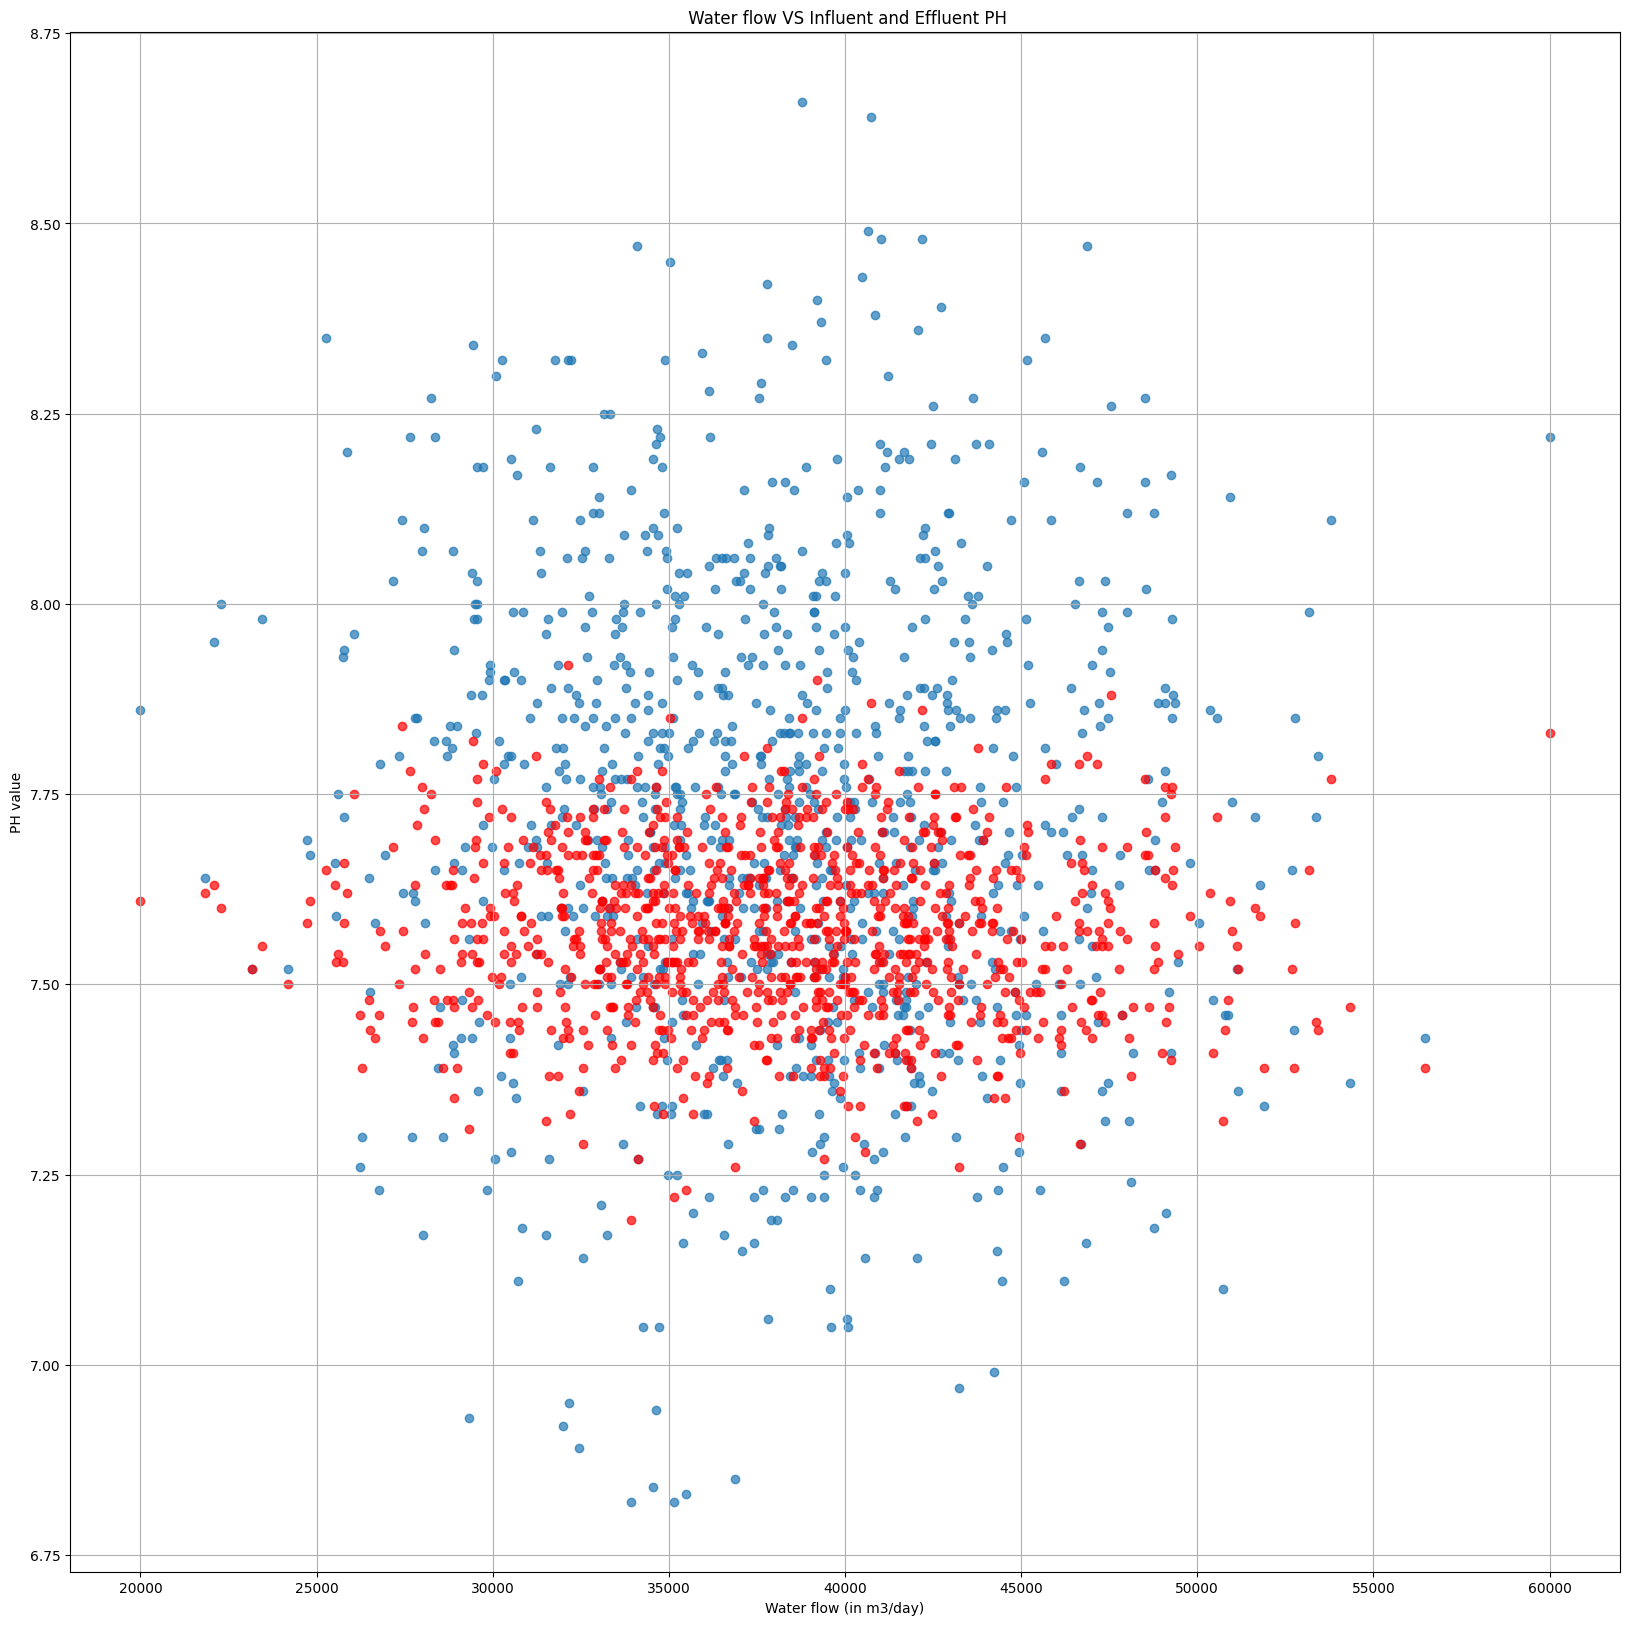

In [60]:
plt.figure(figsize=(20,20))
plt.scatter(df['Q-E'],df['PH-E'],alpha =0.7)
plt.scatter(df['Q-E'],df['PH-S'],color = 'red',alpha =0.7)
plt.xlabel('Water flow (in m3/day)')
plt.ylabel('PH value')
plt.title(' Water flow VS Influent and Effluent PH')
plt.grid(True)
plt.show()

### Heatmap for correlation of BOD with other parameters

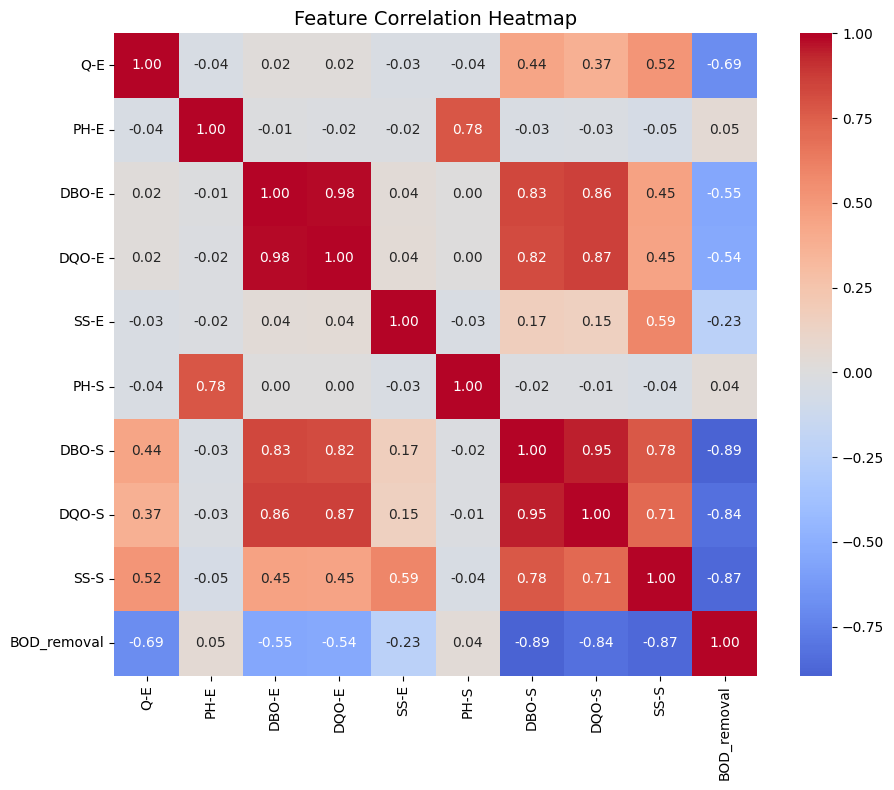

In [32]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm',
            center=0,
            square=True)
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

#### Now we have seen that BOD at exit mostly depends on flow rate, COD, inlet BOD, and solid substance

#### Splitting the data for model training

In [47]:
from sklearn.model_selection import train_test_split
x = df[['Q-E','DBO-E', 'DQO-E','SS-E']]
y = df['DBO-S']
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state =42)

In [48]:
x_train

,Q-E,DBO-E,DQO-E,SS-E
29,36249.8,190.5,419.8,260.1
535,38284.4,202.3,477.3,188.1
695,36142.7,305.9,663.3,210.1
557,35404.7,220.2,487.2,238.0
836,47303.0,334.2,776.7,196.6
...,...,...,...,...
106,49317.1,166.0,343.7,205.3
270,46647.6,240.9,524.7,213.4
860,39217.5,188.1,405.4,196.2
435,38444.6,197.8,452.8,254.8


In [49]:
y_train

29     16.7
535    11.1
695    33.5
557    17.4
836    60.0
       ... 
106    24.8
270    29.3
860    13.1
435    21.4
102    13.0
Name: DBO-S, Length: 800, dtype: float64

### Training the different models to choose the best one

In [50]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test) 

In [51]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [52]:
print(x_train_scaled.shape)
print(x_test_scaled.shape)

(800, 4)
(200, 4)


In [53]:
models = { 'Linear Regressor' : LinearRegression(),
           'Random Forest' : RandomForestRegressor( n_estimators=200,max_depth=10, min_samples_split=5,min_samples_leaf=2,random_state=42),
           'XGBoost' : XGBRegressor(n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbosity=0)}
result = {}
for name, model in models.items():
    model.fit(x_train_scaled,y_train)
    y_pred = model.predict(x_test_scaled)

    
    rmse = np.sqrt(mean_squared_error(y_test,y_pred))
    mae = mean_absolute_error(y_test,y_pred)
    r2 = r2_score(y_test,y_pred)
    result[name] = {'RMSE' : round(rmse,2),
    'MAE' : round(mae,2),
    'R2' : round(r2,4)}

result_df = pd.DataFrame(result).T
print(result_df)

                  RMSE   MAE      R2
Linear Regressor  3.92  3.12  0.8929
Random Forest     4.03  3.17  0.8866
XGBoost           3.81  3.01  0.8988


##### Model explains 89.88% of the variance in effluent BOD
##### XGBoost beats Linear Regression — means non-linear relationships exist
##### RMSE of 3.81 mg/L is very good for BOD prediction

In [54]:
best_model = models['XGBoost']

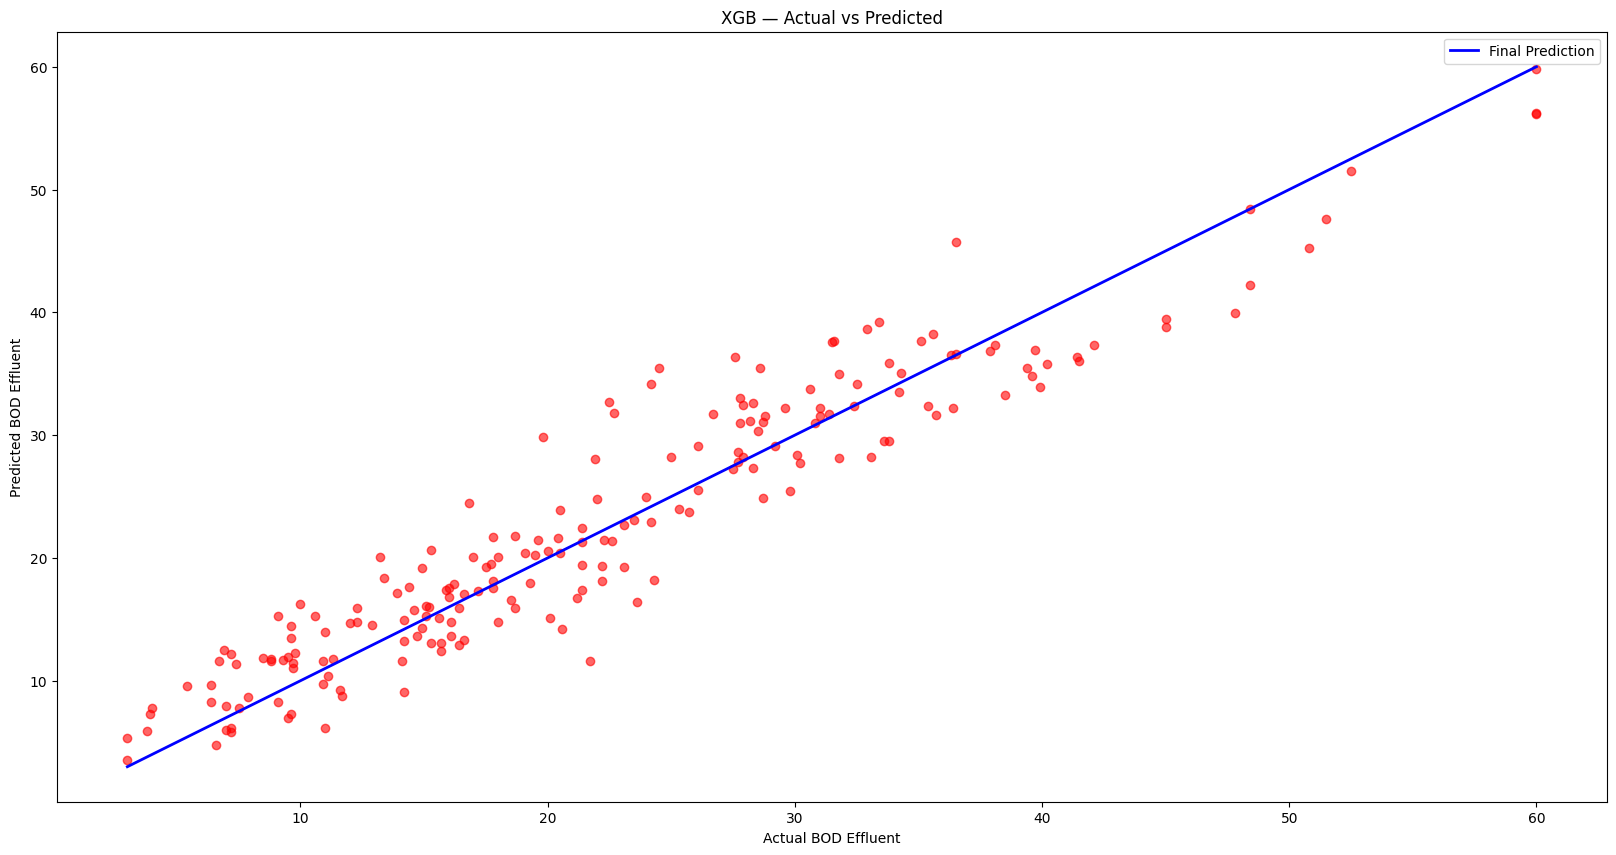

In [55]:
plt.figure(figsize=(20,10))
plt.scatter(y_test,y_pred,alpha =0.6, color = "red")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="blue", linewidth=2, label="Final Prediction")
plt.xlabel("Actual BOD Effluent")
plt.ylabel("Predicted BOD Effluent")
plt.title("XGB — Actual vs Predicted")
plt.legend()
plt.show()

In [56]:
import os
import pickle
os.makedirs("models",exist_ok = True)
with open("models/XGB_wastewater_model.pkl","wb") as f:
    pickle.dump(best_model,f)

In [61]:
with open("models/XGB_wastewater_model.pkl","rb") as f:
     loaded_model = pickle.load(f)
print("Model loaded successfully")

Model loaded successfully


### Using Shap feature to explain the prediction outcomes 

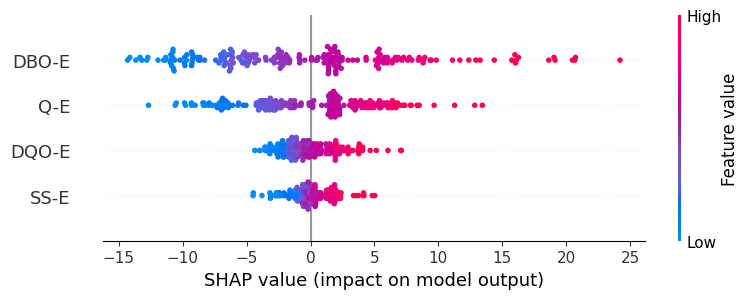

In [58]:
import shap

best_model = models['XGBoost']

explainer = shap.TreeExplainer(best_model, 
                                feature_perturbation='tree_path_dependent')
shap_values = explainer.shap_values(x_test_scaled)

plt.figure()
shap.summary_plot(shap_values, x_test_scaled,
                  feature_names=x.columns.tolist(),
                  show=True)
plt.show()

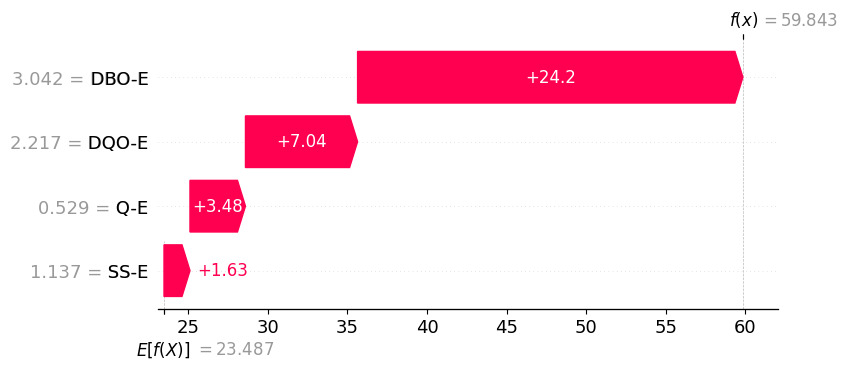

In [59]:
shap.plots.waterfall(shap.Explanation(
    values=shap_values[0],
    base_values=explainer.expected_value,
    data=x_test_scaled[0],
    feature_names=x.columns.tolist()
))
plt.show()

#### SHAP analysis showed that the BOD inlet and the COD inlet are the two strongest predictors of BOD output.